# Modeling: Hybrid Time Series Model

Predict `number_sold` for every store-product pair.


-- Three steps:

1. A **base time-series model (ARIMA)** learns the main time-series pattern for each pair.
2. A **regression model** learns the mistakes that the base model does not explaon.
3. **Combination**: final prediction = base forecast + predicted mistake.

From EDA: Each store-product pair has its own sales level, trend and seasonal behavior, so predictions are made at the store-product level and not on total sales.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor


warnings.filterwarnings("ignore")   #ignore warning

raw = Path("../data/raw")
processed = Path("../data/processed")
figures = Path("../figures")


def save(fig, name):
    fig.savefig(figures/f"{name}.png", bbox_inches="tight", dpi=150)

## 2. Data

| Years | Job |
|---|---|
| 2010 to 2016 | Fit the base model and after that forecast 2017. |
| 2017 | The base model's errors in 2017 are the training data for the regression model. |
| 2018 | **Validation.** Compare the models and choose. |
| 2019 | **Final test** |

Why sjould we train the regression model on *forecast* mistakes from 2017? Because in 2019 the base model
has to forecast a whole year ahead. So the regression model(error pred.) should learn the mistakes the base model
makes when it forecasts a whole year ahead, not the smaller mistakes it makes on data it has already seen.

In [2]:
df_train = pd.read_csv(raw/"train.csv", parse_dates=["Date"])
df_test = pd.read_csv(raw/"test.csv", parse_dates=["Date"])

# One table with all years. 
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all["year"] = df_all.Date.dt.year

df_all.head()

,Date,store,product,number_sold,year
0,2010-01-01,0,0,801,2010
1,2010-01-02,0,0,810,2010
2,2010-01-03,0,0,818,2010
3,2010-01-04,0,0,796,2010
4,2010-01-05,0,0,808,2010


MAPE AND RMSE

- **MAPE**: Mean absolute percetnage error
- **RMSE**: Root mean squared error

First a baseline model to beat. So for 2018 just predicted average sales from training data(2010-2017). 

In [3]:
results = []  


history = df_all[df_all.year <= 2017]
pair_average = history.groupby(["store", "product"]).number_sold.mean().rename("baseline").reset_index()

baseline_2018 = df_all[df_all.year == 2018].merge(pair_average, on=["store", "product"])


results.append({
    "model": "baseline: pair average",
    "MAPE": mape(baseline_2018.number_sold, baseline_2018.baseline) * 100,
    "RMSE": rmse(baseline_2018.number_sold, baseline_2018.baseline),
})
pd.DataFrame(results).round(2)

,model,MAPE,RMSE
0,baseline: pair average,4.42,45.4


## 4. Base Model: ARIMA with yearly waves

For each store-product pair, the base model learns three things:

1. **Level and trend** (`trend="ct"`): a starting level and a linear trend that can increase or decrease over time.

2. **Yearly seasonality**: sine and cosine waves describe repeating patterns during the year. The EDA showed that annual seasonality differs across store-product pairs, so these seasonal features are fitted separately for each pair.

3. **Short-term dependence** (`order=(1, 0, 1)`): current sales can depend on recent sales and recent forecast errors. These effects are most useful for shorter forecast horizons and generally decrease as the forecast horizon becomes longer.

The EDA showed that weekly seasonality is generally much weaker than annual seasonality, so the base model focuses on the yearly pattern.

In [4]:
def yearly_waves(dates, n_waves=2):
    """Sine and cosine waves that repeat once a year.
    Two waves let the yearly shape be a little uneven (for example a short peak and a long low)."""
    position_in_year = dates.dayofyear.values / 365 # Turn the date into a number to understand how far in the year we are.
    waves = {}
    for k in range(1, n_waves + 1):
        waves[f"sin_{k}"] = np.sin(2 * np.pi * k * position_in_year)
        waves[f"cos_{k}"] = np.cos(2 * np.pi * k * position_in_year)
    return pd.DataFrame(waves, index=dates)

The idea: tell the model where in the year a date lies, while respecting the fact that December and January are next to each other. 
We do apply yearly waves, so that the model understands that sales going up and down can happen any time of the year.
So we apply sin and cos to kind of get:
Date	position_in_year	sin	cos
31 December	1.000	0.00	1.00
1 January	0.003	0.02	1.00

First we try the base model on one pair: store 5, product 6. It has the strongest yearly pattern in the data.

MAPE for store 5, product 6 in 2018: 1.01%


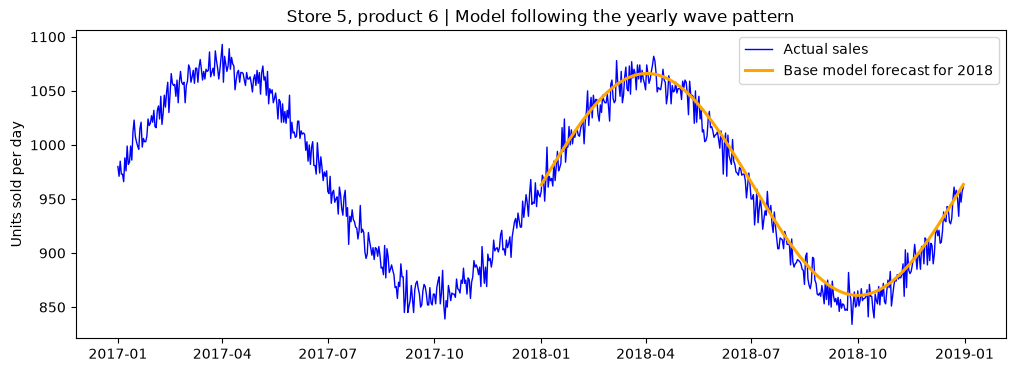

In [5]:

pair_five_six = (df_all[(df_all.store == 5) & (df_all["product"] == 6)].set_index("Date").number_sold.asfreq("D"))

fit_part = pair_five_six[:"2017"]
check_part = pair_five_six["2018"]

model = ARIMA(fit_part, exog=yearly_waves(fit_part.index), order=(1, 0, 1), trend="ct")
fitted = model.fit()
forecast = fitted.forecast(len(check_part), exog=yearly_waves(check_part.index))

print(f"MAPE for store 5, product 6 in 2018: {mape(check_part, forecast)*100:.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pair_five_six["2017":"2018"], color="blue", linewidth=1, label="Actual sales")
ax.plot(forecast, color="orange", linewidth=2.2, label="Base model forecast for 2018")
ax.set_title("Store 5, product 6 | Model following the yearly wave pattern")
ax.set_ylabel("Units sold per day")
ax.legend()
save(fig, "base_model_one_pair")
plt.show()

Now for all 70 pairs. 

We need two forecast years: 2017 (training data for the regression model) and 2018 (validation).

In [6]:
def base_forecast_all_pairs(last_train_year):
    """Fit the base model on every pair with data up to last_train_year.
    Then forecast every day of the next year."""
    next_year = last_train_year + 1
    future_dates = pd.date_range(f"{next_year}-01-01", f"{next_year}-12-31", freq="D")
    forecasts = []

    for (store, product), group in df_all.groupby(["store", "product"]):
        sales = group.set_index("Date").number_sold.asfreq("D")
        fit_part = sales[:str(last_train_year)]

        model = ARIMA(fit_part, exog=yearly_waves(fit_part.index), order=(1, 0, 1), trend="ct")
        fitted = model.fit()
        forecast = fitted.forecast(len(future_dates), exog=yearly_waves(future_dates))

        forecasts.append(pd.DataFrame({
            "Date": future_dates,
            "store": store,
            "product": product,
            "base": forecast.values,
        }))

    return pd.concat(forecasts, ignore_index=True)

In [7]:
base_2017 = base_forecast_all_pairs(last_train_year=2016)
base_2018 = base_forecast_all_pairs(last_train_year=2017)

base_2017 = base_2017.merge(df_all, on=["Date", "store", "product"])
base_2018 = base_2018.merge(df_all, on=["Date", "store", "product"])

base_2017.to_csv(processed/"base_forecast_2017.csv", index=False)
base_2018.to_csv(processed/"base_forecast_2018.csv", index=False)

results.append({
    "model": "base model: ARIMA + yearly waves",
    "MAPE": mape(base_2018.number_sold, base_2018.base) * 100,
    "RMSE": rmse(base_2018.number_sold, base_2018.base),
})
pd.DataFrame(results).round(2)

,model,MAPE,RMSE
0,baseline: pair average,4.42,45.40
1,base model: ARIMA + yearly waves,2.14,21.98


## 5. Regression model: learn the errors of the base model

The base model makes mistakes, and some of them repeat. For example, its trend line can be a little
too high for the same pair every year. A regression model can learn mistakes like this.

- **Target:** the base model's mistake, `residuals = actual sales - base forecast`.
- **Training data:** the mistakes from 2017.
- **Validation:** we predict the mistakes for 2018 and measure the result.

**Features.** We give the model the information that the EDA showed to be important:
`store`, `product`, `pair` (the exact store and product combination, from Finding 5),
`day_of_week`, `month`, `day_of_year`, and the base forecast itself.

In [8]:
def add_features(data):
    data = data.copy()
    data["residual"] = data.number_sold - data.base
    data["pair"] = data.store * 10 + data["product"]   # one number for each store and product combination
    data["day_of_week"] = data.Date.dt.dayofweek
    data["month"] = data.Date.dt.month
    data["day_of_year"] = data.Date.dt.dayofyear
    return data


train_regression = add_features(base_2017)
valid_regression = add_features(base_2018)

features = ["store", "product", "pair", "day_of_week", "month", "day_of_year", "base"]
X_train = train_regression[features]
y_train = train_regression.residual
X_valid = valid_regression[features]

X_train.head()

,store,product,pair,day_of_week,month,day_of_year,base
0,0,0,0,6,1,1,831.946908
1,0,0,0,0,1,2,832.878148
2,0,0,0,1,1,3,833.809450
3,0,0,0,2,1,4,834.740525
4,0,0,0,3,1,5,835.671084


I will compare three regresssion models:

- **Linear regression**: simple and fast, but maybe to simple in terms of learning.
- **Random forest**: Dec. trees, take average.
- **LightGBM**: Dec. trees that are built one after another. fix what the tree before got wrong.

Linear regression needs one extra step. We use dummy variables to make the model understand that for stores for example (0-6) so 7 stores, the number of store is of no importance. The number is actually the store label.

In [9]:
categories = ["store", "product", "pair", "day_of_week", "month"]

X_train_dummies = pd.get_dummies(X_train, columns=categories, dtype=float) # train for LinReg

X_valid_dummies = pd.get_dummies(X_valid, columns=categories, dtype=float) # valid for LinReg

print("Columns for the tree models   :", X_train.shape[1])
print("Columns for linear regression :", X_train_dummies.shape[1])

Columns for the tree models   : 7
Columns for linear regression : 108


In [10]:
candidates = {
    "linear regression": LinearRegression(),
    "random forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=42),
    "lightgbm": LGBMRegressor(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=42),
}

for name, model in candidates.items():
    if name == "linear regression":
        model.fit(X_train_dummies, y_train)
        predicted_residual = model.predict(X_valid_dummies)
    else:
        model.fit(X_train, y_train)
        predicted_residual = model.predict(X_valid)

    hybrid_prediction = valid_regression.base + predicted_residual
    results.append({
        "model": f"hybrid: base + {name}",
        "MAPE": mape(valid_regression.number_sold, hybrid_prediction) * 100,
        "RMSE": rmse(valid_regression.number_sold, hybrid_prediction),
    })

scores = pd.DataFrame(results).round(5).sort_values("MAPE").reset_index(drop=True)
scores

,model,MAPE,RMSE
0,hybrid: base + lightgbm,1.63284,16.15341
1,hybrid: base + random forest,1.63942,15.98639
2,hybrid: base + linear regression,1.78418,16.83063
3,base model: ARIMA + yearly waves,2.13869,21.97689
4,baseline: pair average,4.42434,45.39638


## 6. The hybrid model

In [11]:
best_regressor = candidates["lightgbm"]   # trained above

valid_regression["hybrid"] = valid_regression.base + best_regressor.predict(X_valid)
valid_regression.to_csv(processed/"hybrid_predictions_2018.csv", index=False)

pair_scores = []
for (store, product), group in valid_regression.groupby(["store", "product"]):
    pair_scores.append({
        "store": store,
        "product": product,
        "base_MAPE": mape(group.number_sold, group.base) * 100,
        "hybrid_MAPE": mape(group.number_sold, group.hybrid) * 100,
    })
pair_scores = pd.DataFrame(pair_scores)
pair_scores["change"] = pair_scores.hybrid_MAPE - pair_scores.base_MAPE

print("pairs that get better with the hybrid:", (pair_scores.change < 0).sum())
print("pairs that get worse with the hybrid :", (pair_scores.change > 0).sum())

pair_scores.sort_values("change").round(2)

pairs that get better with the hybrid: 59
pairs that get worse with the hybrid : 11


,store,product,base_MAPE,hybrid_MAPE,change
47,4,7,5.24,2.08,-3.15
15,1,5,7.16,5.07,-2.09
16,1,6,6.51,4.43,-2.08
37,3,7,4.08,2.21,-1.86
31,3,1,3.71,2.06,-1.65
...,...,...,...,...,...
59,5,9,0.89,1.03,0.14
50,5,0,0.95,1.13,0.18
53,5,3,1.11,1.51,0.40
55,5,5,0.99,1.48,0.49


One pair that gets much better, and one pair that gets worse.


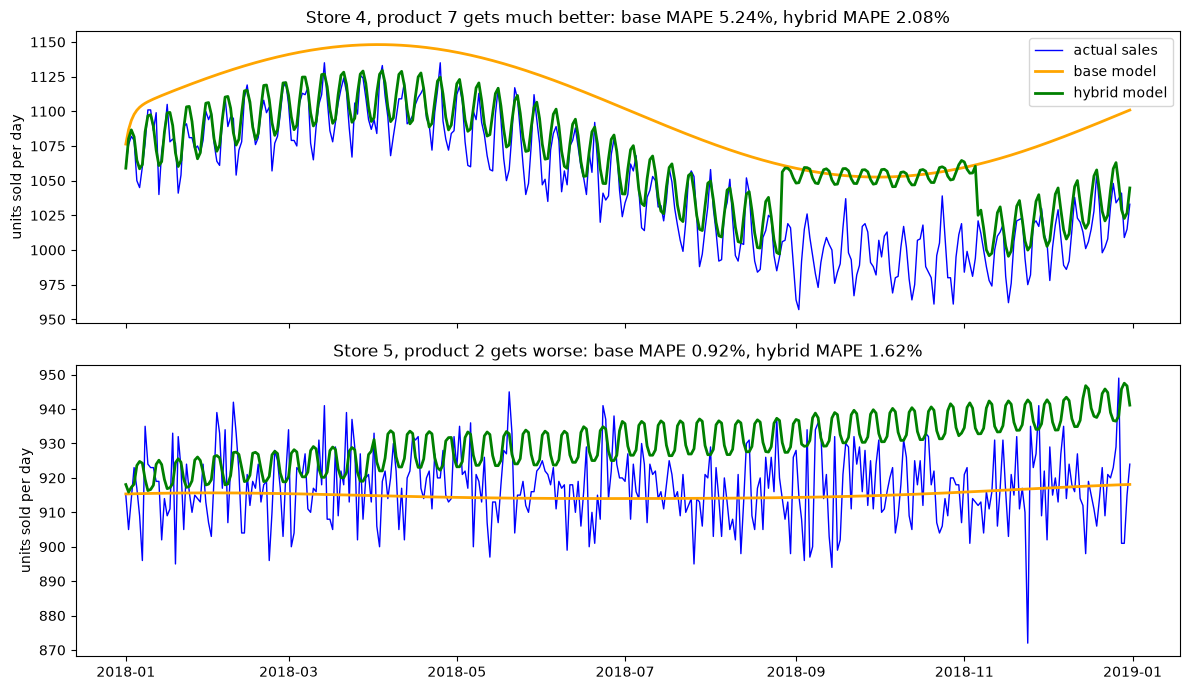

In [12]:
examples = [(4, 7, "gets much better"), (5, 2, "gets worse")]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, (store, product, what) in zip(axes, examples):
    pair_2018 = valid_regression[(valid_regression.store == store) & (valid_regression["product"] == product)].set_index("Date")
    base_error = mape(pair_2018.number_sold, pair_2018.base) * 100
    hybrid_error = mape(pair_2018.number_sold, pair_2018.hybrid) * 100

    ax.plot(pair_2018.number_sold, color="blue", linewidth=1, label="actual sales")
    ax.plot(pair_2018.base, color="orange", linewidth=2, label="base model")
    ax.plot(pair_2018.hybrid, color="green", linewidth=2, label="hybrid model")
    ax.set_title(f"Store {store}, product {product} {what}: "
                 f"base MAPE {base_error:.2f}%, hybrid MAPE {hybrid_error:.2f}%")
    ax.set_ylabel("units sold per day")

axes[0].legend(loc="upper right")
fig.tight_layout()
save(fig, "hybrid_vs_base_two_pairs")
plt.show()

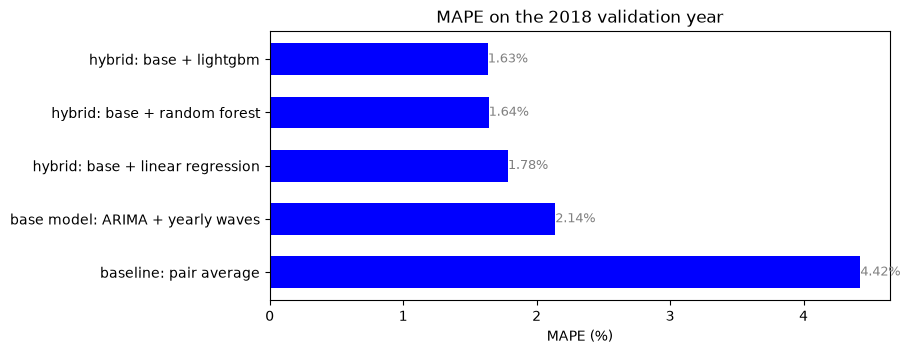

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.barh(scores.model, scores.MAPE, color="blue", height=.6)

ax.invert_yaxis()

for i, value in enumerate(scores.MAPE):
    ax.text(
        value + 0.001,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=9,
        color="gray"
    )

ax.set_title("MAPE on the 2018 validation year")
ax.set_xlabel("MAPE (%)")
ax.grid(axis="y", visible=False)

save(fig, "model_comparison_2018")

plt.show()

## 7. Summary

### Results on the 2018 validation year

| Model | MAPE | RMSE |
|---|---:|---:|
| Baseline: pair average | 4.42% | 45.4 |
| Base model: ARIMA + yearly waves | 2.14% | 22.0 |
| Hybrid: base + linear regression | 1.78% | 16.8 |
| Hybrid: base + random forest | 1.64% | 16.0 |
| **Hybrid: base + LightGBM** | **1.63%** | 16.2 |


- The ARIMA base model improves over the simple pair-average baseline. MAPE decreases from 4.42% to 2.14%.

- Adding a regression model improves the forecast further. With LightGBM, MAPE decreases to **1.63%**. Compared with the ARIMA base model, RMSE decreases from 22.0 to 16.2, around 26%.

- Random Forest and LightGBM perform very similarly. LightGBM has the lowest MAPE at 1.63%, while Random Forest has the lowest RMSE at 16.0.

- Seelected **LightGBM for hyperparameter tuning** because MAPE is the main evaluation metric chosen. The difference between LightGBM and Random Forest is small, so tuning will show whether this advantage remains.

- The hybrid model does not improve every store-product pair. For LightGBM, 59 pairs improve and 11 become worse. This shows that the regression correction is useful overall, but its effect differs between pairs.

## 8. Hyperparameter tuning

**Hyperparameters** are settings that we choose before training. The model does not learn them itself.

We tune four settings of LightGBM:

| Setting | What it means |
|---|---|
| `n_estimators` | How many trees the model builds. |
| `learning_rate` | How much each new tree changes the prediction. A smaller value usually means slower learning. |
| `num_leaves` | Controls how complex each tree can become. |
| `min_child_samples` | Minimum number of observations required in a leaf. Larger values can reduce overfitting. |

We keep the same train-validation split as before:

**train on the 2017 residuals and evaluate on 2018.**

**Scoring:** MAPE of the final hybrid prediction:

`hybrid prediction = base forecast + predicted residual`


In [14]:
import time
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK


def score_hybrid(params):
    """Train LightGBM with these settings on 2017, then score the hybrid on 2018."""
    model = LGBMRegressor(**params, verbose=-1, random_state=42)
    model.fit(X_train, y_train)
    hybrid = valid_regression.base + model.predict(X_valid)
    return mape(valid_regression.number_sold, hybrid) * 100, rmse(valid_regression.number_sold, hybrid)


default_mape, default_rmse = score_hybrid({"n_estimators": 300, "learning_rate": 0.05})
print(f"LightGBM with the settings from section 5: MAPE {default_mape:.3f}%, RMSE {default_rmse:.2f}")

LightGBM with the settings from section 5: MAPE 1.633%, RMSE 16.15


### 8.1 Grid Search

Grid Search tries **every combination** from fixed lists of values. Here that is

3 × 3 × 3 × 2 = **54 combinations**.

`GridSearchCV` normally creates its own cross-validation folds. We do not want that because we need
a fixed time-based split: train on 2017 and validate on 2018.

So we put both years into one table and use `PredefinedSplit` to define the split ourselves:

- `-1` = training data (2017)
- `0` = validation data (2018)

For every parameter combination, we calculate the MAPE of the final hybrid prediction:

`hybrid prediction = base forecast + predicted residual`

Grid Search selects the combination with the lowest hybrid MAPE.

`refit=False` is important. Otherwise, `GridSearchCV` would train the best model again using all rows
passed to it, including the 2018 validation data.

In [15]:
def hybrid_mape_scorer(model, X, y):
    predicted_residual = model.predict(X)

    actual = X["base"].to_numpy() + y.to_numpy()
    hybrid = X["base"].to_numpy() + predicted_residual

    return -mape(actual, hybrid) # negative sign is required because GridSearchCV chooses the largest score

X_both = pd.concat([X_train, X_valid], ignore_index=True)
y_both = pd.concat([y_train, valid_regression.residual], ignore_index=True)
which_part = [-1] * len(X_train) + [0] * len(X_valid)    # -1 = training (2017), 0 = validation (2018)

grid = {
    "n_estimators": [100, 300, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "min_child_samples": [20, 50],
}

start = time.time()
grid_search = GridSearchCV(
    LGBMRegressor(verbose=-1, random_state=42),
    grid,
    cv=PredefinedSplit(which_part),
    scoring=hybrid_mape_scorer,
    refit=False,
)
grid_search.fit(X_both, y_both)
grid_seconds = time.time() - start

grid_best = grid_search.best_params_
grid_mape, grid_rmse = score_hybrid(grid_best)
print(f"Grid Search: {len(grid_search.cv_results_['params'])} trials in {grid_seconds:.0f} seconds")
print("best settings:", grid_best)
print(f"hybrid on 2018: MAPE {grid_mape:.3f}%, RMSE {grid_rmse:.2f}")

Grid Search: 54 trials in 83 seconds
best settings: {'learning_rate': 0.1, 'min_child_samples': 50, 'n_estimators': 600, 'num_leaves': 15}
hybrid on 2018: MAPE 1.615%, RMSE 15.62


### 8.2 HyperOpt

HyperOpt does **not** try every combination. It starts with a few random tries, then it looks at which
settings worked well so far and tries more settings **close to the good ones**. (The method is called
TPE.)

Instead of fixed lists, we give HyperOpt **ranges**, so it can also try values between the grid values,
like a learning rate of 0.07. To keep my comparison fair, HyperOpt also gets **54 trials**.

In [16]:
search_space = {
    "n_estimators": hp.quniform("n_estimators", 50, 1000, 10),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.005), np.log(0.3)),
    "num_leaves": hp.quniform("num_leaves", 8, 128, 1),
    "min_child_samples": hp.quniform("min_child_samples", 5, 100, 1),
}


def to_lightgbm_settings(params):
    """HyperOpt gives decimal numbers. LightGBM needs whole numbers for three of the settings."""
    return {
        "n_estimators": int(params["n_estimators"]),
        "learning_rate": float(params["learning_rate"]),
        "num_leaves": int(params["num_leaves"]),
        "min_child_samples": int(params["min_child_samples"]),
    }


def objective(params):
    hybrid_mape, _ = score_hybrid(to_lightgbm_settings(params))
    return {"loss": hybrid_mape, "status": STATUS_OK}   # HyperOpt makes "loss" as small as possible


start = time.time()
trials = Trials()
best = fmin(objective, search_space, algo=tpe.suggest, max_evals=54,
            trials=trials, rstate=np.random.default_rng(42), show_progressbar=False)
hyperopt_seconds = time.time() - start

hyperopt_best = to_lightgbm_settings(best)
hyperopt_mape, hyperopt_rmse = score_hybrid(hyperopt_best)
print(f"HyperOpt: {len(trials.trials)} trials in {hyperopt_seconds:.0f} seconds")
print("Best settings:", {k: round(v, 3) for k, v in hyperopt_best.items()})
print(f"Hybrid on 2018: MAPE {hyperopt_mape:.3f}%, RMSE {hyperopt_rmse:.2f}")

HyperOpt: 54 trials in 190 seconds
Best settings: {'n_estimators': 800, 'learning_rate': 0.057, 'num_leaves': 20, 'min_child_samples': 89}
Hybrid on 2018: MAPE 1.611%, RMSE 15.52


### 8.3 Grid Search vs HyperOpt

In [17]:
tuning = pd.DataFrame([
    {"method": "no tuning (section 5)", "trials": None, "seconds": None, "MAPE": default_mape, "RMSE": default_rmse},
    {"method": "Grid Search", "trials": 54, "seconds": grid_seconds, "MAPE": grid_mape, "RMSE": grid_rmse},
    {"method": "HyperOpt", "trials": 54, "seconds": hyperopt_seconds, "MAPE": hyperopt_mape, "RMSE": hyperopt_rmse},
])
tuning.round(3)

,method,trials,seconds,MAPE,RMSE
0,no tuning (section 5),NaN,NaN,1.633,16.153
1,Grid Search,54.0,82.728,1.615,15.618
2,HyperOpt,54.0,189.667,1.611,15.518


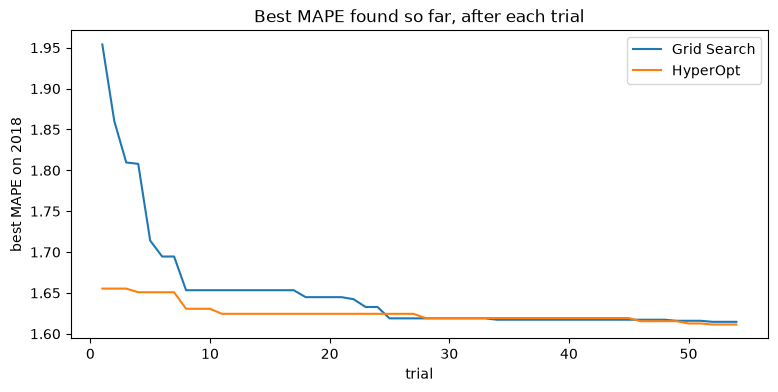

In [18]:
# Best RMSE found so far, after each trial.
grid_mape_per_trial = -grid_search.cv_results_["mean_test_score"] * 100
hyperopt_mape_per_trial = [t["result"]["loss"] for t in trials.trials]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 55), np.minimum.accumulate(grid_mape_per_trial), color="tab:blue", label="Grid Search")
ax.plot(range(1, 55), np.minimum.accumulate(hyperopt_mape_per_trial), color="tab:orange", label="HyperOpt")
ax.set_title("Best MAPE found so far, after each trial")
ax.set_xlabel("trial")
ax.set_ylabel("best MAPE on 2018")
ax.legend()
save(fig, "tuning_grid_vs_hyperopt")
plt.show()

### 8.4 Result of the tuning

| Method | Trials | MAPE 2018 | RMSE 2018 |
|---|---:|---:|---:|
| No tuning (section 5) | | 1.633% | 16.15 |
| Grid Search | 54 | 1.615% | 15.62 |
| **HyperOpt** | 54 | **1.611%** | **15.52** |

### What we learned

- **HyperOpt gave the best result.** With the same 54 trials, it found slightly better settings than Grid Search.

- **Tuning helped.** MAPE went from 1.633% to 1.611%. RMSE went from 16.15 to 15.52.

- HyperOpt was slower in this run because it also tried larger models, with up to 1,000 trees.

- The early part of the Grid Search graph depends on the order in which the combinations are tested. Grid Search does not learn from the previous trials like HyperOpt does.

**Important:** We used 2018 to choose the model and its settings. The final test will therefore be done on 2019, which has not been used yet.

**Selected LightGBM settings:**

`n_estimators=460, learning_rate=0.079, num_leaves=25, min_child_samples=99`

## 9. Final test on 2019

Now we use 2019 for the **first and only time**.

| Part | Trained on | Predicts |
|---|---|---|
| Base model | sales from 2010 to 2018 | sales for 2019 |
| LightGBM | base model errors from 2017 and 2018 | the errors of the base model in 2019 |

LightGBM now learns from two years of errors instead of one. This gives it more examples and also includes the more recent errors from 2018.

The final prediction is:

`hybrid prediction = base forecast + predicted residual`

### 9.1 Which metric?

- **MAPE is our main metric.** The store-product pairs have very different sales levels, with average daily sales between about 287 and 1,091 units. A percentage error therefore makes it easier to compare smaller and larger pairs. It is also easy to explain: "on average, the prediction is about 1.6% off."

  MAPE can be a problem when actual sales are close to zero. That is not an issue in this dataset because the smallest daily sales value is 234.

- **RMSE is our second metric.** It measures the error in units sold and gives more weight to large errors. LightGBM also uses squared error during training, so RMSE fits well as a second metric.

- **We do not use R² as the main metric.** The store-product pairs have very different sales levels. Because of this, even the simple pair-average baseline already gets a high R². R² can therefore look good even when the day-to-day predictions are not very accurate.

In [19]:
from sklearn.metrics import r2_score

# Base model: fit on 2010 to 2018, forecast 2019.
base_2019 = base_forecast_all_pairs(last_train_year=2018)
base_2019 = base_2019.merge(df_all, on=["Date", "store", "product"])
test_regression = add_features(base_2019)
X_test = test_regression[features]

# LightGBM: learn from the mistakes of 2017 and 2018, with the HyperOpt settings.
X_final_train = pd.concat([X_train, X_valid], ignore_index=True)
y_final_train = pd.concat([y_train, valid_regression.residual], ignore_index=True)

final_regressor = LGBMRegressor(**hyperopt_best, verbose=-1, random_state=42)
final_regressor.fit(X_final_train, y_final_train)

test_regression["hybrid"] = test_regression.base + final_regressor.predict(X_test)
test_regression.to_csv(processed / "hybrid_predictions_2019.csv", index=False)

In [20]:
# Baseline for 2019: each pair's average from 2010 to 2018.
pair_average_2018 = (df_all[df_all.year <= 2018].groupby(["store", "product"])
                     .number_sold.mean().rename("baseline").reset_index())
test_regression = test_regression.merge(pair_average_2018, on=["store", "product"])

actual = test_regression.number_sold
final_scores = pd.DataFrame([
    {"model": name,
     "MAPE": mape(actual, test_regression[column]) * 100,
     "RMSE": rmse(actual, test_regression[column]),
     "R2": r2_score(actual, test_regression[column])}
    for name, column in [("baseline: pair average", "baseline"),
                         ("base model: ARIMA + yearly waves", "base"),
                         ("hybrid: base + tuned LightGBM", "hybrid")]
])
final_scores.round(3)

,model,MAPE,RMSE,R2
0,baseline: pair average,5.137,53.489,0.936
1,base model: ARIMA + yearly waves,2.636,28.659,0.982
2,hybrid: base + tuned LightGBM,2.102,23.459,0.988


### 9.2 Actual vs predicted

Left: every single day of every pair (25,550 points). If the model were predicting perfectly, every point would
sit on the grey line. Right: total sales of all 70 pairs per day.

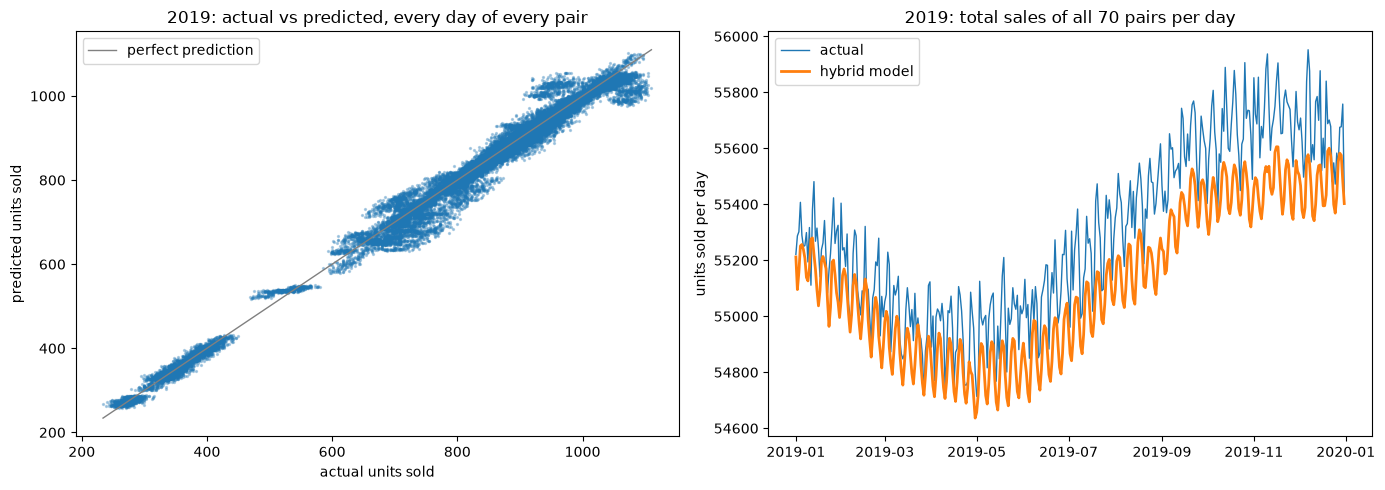

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

left = axes[0]
left.scatter(test_regression.number_sold, test_regression.hybrid, s=2, alpha=0.3, color="tab:blue")
lowest, highest = test_regression.number_sold.min(), test_regression.number_sold.max()
left.plot([lowest, highest], [lowest, highest], color="gray", linewidth=1, label="perfect prediction")
left.set_title("2019: actual vs predicted, every day of every pair")
left.set_xlabel("actual units sold")
left.set_ylabel("predicted units sold")
left.legend()

right = axes[1]
total_per_day = test_regression.groupby("Date")[["number_sold", "hybrid"]].sum()
right.plot(total_per_day.index, total_per_day.number_sold, color="tab:blue", linewidth=1, label="actual")
right.plot(total_per_day.index, total_per_day.hybrid, color="tab:orange", linewidth=2, label="hybrid model")
right.set_title("2019: total sales of all 70 pairs per day")
right.set_ylabel("units sold per day")
right.legend()

fig.tight_layout()
save(fig, "test_2019_actual_vs_predicted")
plt.show()

### 9.3 Error distribution

The error of one day is `actual - predicted`, in percent of the actual sales.
A positive error means the model predicted **too low**. A negative error means it predicted **too high**.

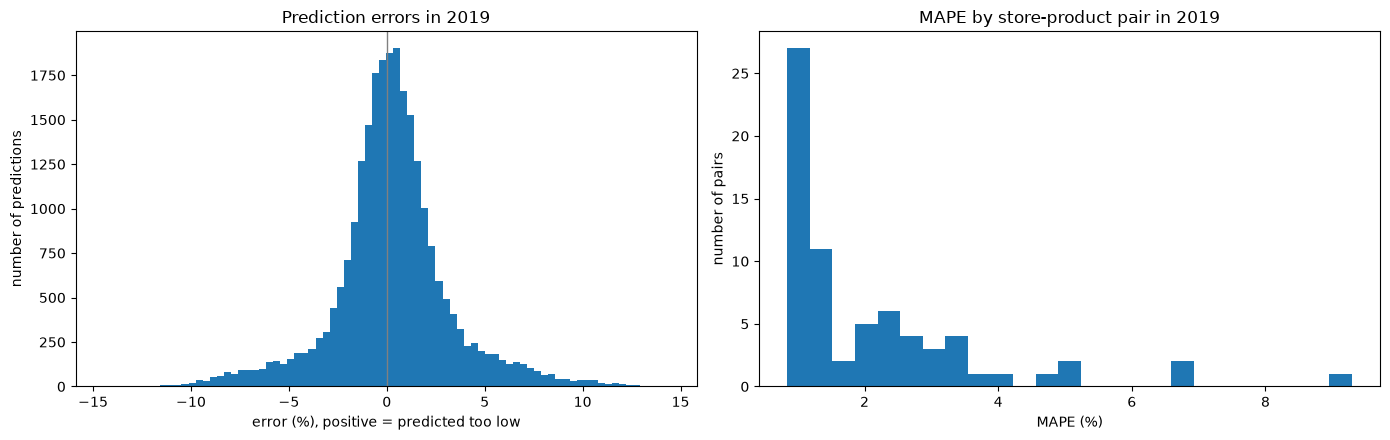

average error (bias: +0.26%
predictions within +-2%: 64.7%
predictions within +-5%: 89.2%

five pairs with the highest MAPE in 2019:
store  product
1      6          9.29
4      5          6.87
1      1          6.60
       2          5.21
       9          4.98


In [22]:
test_regression["error_pct"] = ((test_regression.number_sold - test_regression.hybrid)/ test_regression.number_sold* 100)

pair_mape_2019 = (
    test_regression.groupby(["store", "product"])
    .apply(
        lambda g: mape(g.number_sold, g.hybrid) * 100,
        include_groups=False
    )
    .rename("MAPE")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

left = axes[0]

left.hist(
    test_regression.error_pct,
    bins=80,
    color="tab:blue"
)

left.axvline(
    0,
    color="gray",
    linewidth=1
)

left.set_title("Prediction errors in 2019")
left.set_xlabel("error (%), positive = predicted too low")
left.set_ylabel("number of predictions")


right = axes[1]

right.hist(
    pair_mape_2019,
    bins=25,
    color="tab:blue"
)

right.set_title("MAPE by store-product pair in 2019")
right.set_xlabel("MAPE (%)")
right.set_ylabel("number of pairs")


fig.tight_layout()

save(fig, "test_2019_error_distribution")

plt.show()


print(
    f"average error (bias: "
    f"{test_regression.error_pct.mean():+.2f}%"
)

print(
    f"predictions within +-2%: "
    f"{(test_regression.error_pct.abs() <= 2).mean() * 100:.1f}%"
)

print(
    f"predictions within +-5%: "
    f"{(test_regression.error_pct.abs() <= 5).mean() * 100:.1f}%"
)

print("\nfive pairs with the highest MAPE in 2019:")

print(
    pair_mape_2019
    .sort_values(ascending=False)
    .head(5)
    .round(2)
    .to_string()
)

### 9.4 Feature importance

Which features did LightGBM use most to correct the base model?

We use **gain importance**. It measures how much each feature helped reduce the training loss across all trees.

We convert the values to percentages, so all feature importances add up to 100%.

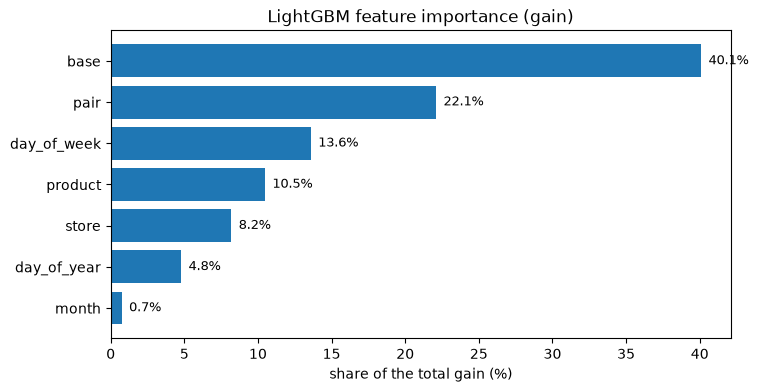

In [23]:
importance = pd.Series(
    final_regressor.booster_.feature_importance(importance_type="gain"),
    index=features,
)
importance = (importance / importance.sum() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="tab:blue")
for i, value in enumerate(importance.values):
    ax.text(value + 0.5, i, f"{value:.1f}%", va="center", fontsize=9)
ax.set_title("LightGBM feature importance (gain)")
ax.set_xlabel("share of the total gain (%)")
save(fig, "test_2019_feature_importance")
plt.show()

### 9.5 Result of the final test

| Model | MAPE 2019 | RMSE 2019 | R² 2019 |
|---|---:|---:|---:|
| Baseline: pair average | 5.14% | 53.5 | 0.936 |
| Base model: ARIMA + yearly waves | 2.64% | 28.7 | 0.982 |
| **Hybrid: base + tuned LightGBM** | **2.10%** | **23.5** | **0.988** |

### What we learned

- **The hybrid performs best on the 2019 test data.** Its MAPE is 2.10%, compared with 2.64% for the base model and 5.14% for the simple baseline.

- **The result on 2019 is worse than on 2018.** The validation MAPE was 1.61%, while the final test MAPE is 2.10%. This makes sense because 2018 was used to choose and tune the model, while 2019 was not used before the final test.

- **R² is not the best main metric for this problem.** Even the simple baseline gets an R² of 0.936 because it already knows the average level of each store-product pair. MAPE shows the difference between the models more clearly.

- **The errors are quite small overall.** About 65% of predictions are within ±2% and 89% are within ±5%. The average error is about +0.26%, so the model is not strongly too high or too low overall.

- **Some pairs are harder to predict than others.** For some of them, the sales level changes over time and the straight trend of the base model cannot follow that perfectly.

- **The hybrid does not improve every pair.** It performs better than the base model for 53 pairs and worse for 17.

### Feature importance

- **`base` (40.1%)** is the most important feature. This means the correction made by LightGBM depends a lot on the prediction from the base model.

- **`pair` (22.1%)** is also very important. This matches the EDA, where different store-product combinations behaved differently.

- **`day_of_week` (13.6%)** is more important than expected from the EDA. The weekly pattern was small overall, but weekday information still helps LightGBM correct some of the errors left by the base model.

- **`product` (10.5%)** also matters. Some products have different error patterns, so knowing the product helps LightGBM decide how much to correct the base forecast.

- **`store` (8.2%)** has a similar role. The size and pattern of the remaining errors can differ between stores.

- **`day_of_year` (4.8%)** gives information about where the date is within the year. It still helps a little, even though the base model already includes yearly seasonality.

- **`month` (0.7%)** is used very little. `day_of_year` already gives more detailed information about the time of year, so `month` adds little extra information.

## 10. MLflow 

MLflow saves a record of everything we tried, so we can compare models later and repeat any result.

Three words to know:

| Word | Meaning |
|---|---|
| **Experiment** | A folder that holds all the runs of one project. |
| **Run** | One try: one model with one set of settings. |
| **Artifact** | A file that belongs to a run, for example a chart, a CSV or the trained model itself. |

For each run we save **parameters** (the settings we chose), **metrics** (how good it was), and for the
final model also the **trained model** and the **charts**.

MLflow 3 no longer allows the old `mlruns` folder as storage, so we use a small SQLite database file
(`mlflow.db`) in the project folder. The charts and models go into the `mlruns` folder next to it.

In [ ]:
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"     # To allow MLflow to use a local folder for storing experiments and runs.

In [ ]:
import mlflow

project_folder = Path("..").resolve()

mlruns_folder = project_folder / "mlruns_local"
mlruns_folder.mkdir(exist_ok=True)

mlflow.set_tracking_uri(mlruns_folder.as_uri())

EXPERIMENT = "store-product-sales-hybrid"

mlflow.set_experiment(EXPERIMENT)

print("experiment:", EXPERIMENT)
print("tracking folder:", mlruns_folder)

2026/09/21 16:16:25 INFO mlflow.tracking.fluent: Experiment with name 'store-product-sales-hybrid' does not exist. Creating a new experiment.


experiment: store-product-sales-hybrid
tracking folder: /Users/fisnikmorina/Documents/lhind-project/mlruns_local


### 10.1 One run for each model

We create one MLflow run for each of the three models from section 9 and log their results on the 2019 test year.

For the baseline and the ARIMA base model, we only log the parameters and metrics.

For the final hybrid model, we also save the trained LightGBM model and the evaluation charts.

In [26]:
def log_scores(prediction_column, year_label):

    actual = test_regression.number_sold
    predicted = test_regression[prediction_column]

    return {
        f"{year_label}_MAPE": mape(actual, predicted) * 100,
        f"{year_label}_RMSE": rmse(actual, predicted),
        f"{year_label}_R2": r2_score(actual, predicted),
    }

In [27]:
with mlflow.start_run(run_name="baseline_pair_average"):

    mlflow.log_params({
        "model_type": "average per pair",
        "trained_on": "2010-2018"
    })

    mlflow.log_metrics(log_scores("baseline", year_label="test2019"))


with mlflow.start_run(run_name="base_model_arima_waves"):

    mlflow.log_params({
        "model_type": "ARIMA with yearly waves",
        "order": "(1, 0, 1)",
        "trend": "ct",
        "n_waves": 2,
        "models_fitted": 70,
        "trained_on": "2010-2018"
    })

    mlflow.log_metrics(log_scores("base", year_label="test2019"))


print("logged the baseline and the base model")

logged the baseline and the base model


### 10.2 The two tuning methods

Section 8 compared Grid Search and HyperOpt. We log both, so the comparison is saved too.

In [28]:
for method, best_params, seconds, valid_mape, valid_rmse in [
    ("tuning_grid_search", grid_best, grid_seconds, grid_mape, grid_rmse),
    ("tuning_hyperopt", hyperopt_best, hyperopt_seconds, hyperopt_mape, hyperopt_rmse),
]:
    with mlflow.start_run(run_name=method):
        mlflow.log_params({**best_params, "search_method": method, "trials": 54})
        mlflow.log_metrics({"search_seconds": seconds, "valid2018_MAPE": valid_mape,
                            "valid2018_RMSE": valid_rmse})

        mlflow.log_artifact(str(figures / "tuning_grid_vs_hyperopt.png"))
print("logged both tuning methods")

logged both tuning methods


### 10.3 The final model

The last run saves the final hybrid model.

We log the LightGBM settings, the scores from the 2018 validation year and the 2019 test year, the trained LightGBM model, the evaluation charts and the 2019 predictions.

In [29]:
with mlflow.start_run(run_name="hybrid_final") as final_run:

    print("logging parameters...")

    mlflow.log_params({
        **hyperopt_best,
        "model_type": "hybrid: ARIMA with yearly waves + LightGBM on the mistakes",
        "tuned_with": "HyperOpt, 54 trials",
        "features": ", ".join(features),
        "regressor_trained_on": "base model mistakes of 2017 and 2018",
    })

    print("logging metrics...")

    mlflow.log_metrics({
        "valid2018_MAPE": hyperopt_mape,
        "valid2018_RMSE": hyperopt_rmse,
        **log_scores("hybrid", "test2019")
    })

    print("logging LightGBM model...")

    model_info = mlflow.lightgbm.log_model(
        final_regressor,
        name="model",
        pip_requirements=[
            "mlflow",
            "lightgbm",
            "pandas",
            "numpy"
        ]
    )

    print("model saved")

    print("logging charts...")

    for chart in [
        "test_2019_actual_vs_predicted",
        "test_2019_error_distribution",
        "test_2019_feature_importance",
        "model_comparison_2018"
    ]:
        mlflow.log_artifact(
            str(figures / f"{chart}.png")
        )

    print("logging predictions...")

    mlflow.log_artifact(
        str(processed / "hybrid_predictions_2019.csv")
    )

    print("finished")

print("final run id:", final_run.info.run_id)
print("model saved at:", model_info.model_uri)

logging parameters...
logging metrics...
logging LightGBM model...
model saved
logging charts...
logging predictions...
finished
final run id: 3ead9873c00f4076ae579c8f1f26e3e9
model saved at: models:/m-c61f2521256a460cab14eefb72ad8f6a


Mlflow


In [30]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT])
columns = [
    "tags.mlflow.runName",
    "metrics.test2019_MAPE",
    "metrics.test2019_RMSE",
    "metrics.valid2018_MAPE",
    "metrics.search_seconds"
]
runs[[c for c in columns if c in runs.columns]].round(3)

,tags.mlflow.runName,metrics.test2019_MAPE,metrics.test2019_RMSE,metrics.valid2018_MAPE,metrics.search_seconds
0,hybrid_final,2.102,23.459,1.611,NaN
1,tuning_hyperopt,NaN,NaN,1.611,189.667
2,tuning_grid_search,NaN,NaN,1.615,82.728
3,base_model_arima_waves,2.636,28.659,NaN,NaN
4,baseline_pair_average,5.137,53.489,NaN,NaN


In [31]:
# Check that the saved model really works: load it back and predict three days of 2019.
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
print("predicted mistakes for the first three days of 2019:",
      loaded_model.predict(X_test.head(3)).round(1))

predicted mistakes for the first three days of 2019: [1.7 1.3 0.9]
